# 0 Imports

In [62]:
import ast
import nltk
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.options.mode.chained_assignment = None

# 1 Carregando datasets

## 1.1 Filmes

In [2]:
df_filmes = pd.read_csv('dados/dataset_filmes.csv')

In [5]:
df_filmes.shape

(4803, 20)

In [6]:
df_filmes.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## 1.2 Elenco

In [3]:
df_elenco = pd.read_csv('dados/dataset_elenco.csv')

In [8]:
df_elenco.shape

(4803, 4)

In [11]:
df_elenco.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## 1.3 Unindo bases

In [4]:
df_geral = pd.merge(df_filmes, df_elenco, on='title')

In [13]:
df_geral.shape

(4809, 23)

In [14]:
df_geral.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [15]:
df_geral.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status               

In [5]:
df_geral.to_csv('dados/dataset_geral.csv', index=False)

# 2 Análise Exploratória dos Dados

In [2]:
df_geral = pd.read_csv('dados/dataset_geral.csv')

## 2.1 Identificando nulos e duplicatas

### Nulos

In [6]:
df_geral.isnull().sum()

budget                     0
genres                     0
homepage                3096
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
movie_id                   0
cast                       0
crew                       0
dtype: int64

### Duplicatas

In [9]:
df_geral.duplicated().sum()

np.int64(0)

## 2.2 Descritivas

### 2.2.1 Numéricas

In [3]:
df_geral_numericas = df_geral.select_dtypes(exclude=['object'])
df_geral_numericas.drop(columns=['id', 'movie_id'], inplace=True)
df_geral_numericas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        4809 non-null   int64  
 1   popularity    4809 non-null   float64
 2   revenue       4809 non-null   int64  
 3   runtime       4807 non-null   float64
 4   vote_average  4809 non-null   float64
 5   vote_count    4809 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 225.6 KB


#### Distribuição

In [14]:
df_geral_numericas.describe()

,budget,popularity,revenue,runtime,vote_average,vote_count
count,4.809000e+03,4809.000000,4.809000e+03,4807.000000,4809.000000,4809.000000
mean,2.902780e+07,21.491664,8.227511e+07,106.882255,6.092514,690.331670
std,4.070473e+07,31.803366,1.628379e+08,22.602535,1.193989,1234.187111
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.800000e+05,4.667230,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,28.350529,9.291317e+07,118.000000,6.800000,737.000000
max,3.800000e+08,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


#### Matriz de correlação - Pearson e Spearman

In [16]:
corr_pearson = df_geral_numericas.corr(method='pearson')
corr_spearman = df_geral_numericas.corr(method='spearman')

print('Pearson correlation matrix:')
print(corr_pearson)

print('\nSpearman correlation matrix:')
print(corr_spearman)

Pearson correlation matrix:
                budget  popularity   revenue   runtime  vote_average  \
budget        1.000000    0.505515  0.730584  0.269903      0.093061   
popularity    0.505515    1.000000  0.644724  0.225775      0.273964   
revenue       0.730584    0.644724  1.000000  0.251341      0.197336   
runtime       0.269903    0.225775  0.251341  1.000000      0.375072   
vote_average  0.093061    0.273964  0.197336  0.375072      1.000000   
vote_count    0.593222    0.778205  0.781468  0.272235      0.313002   

              vote_count  
budget          0.593222  
popularity      0.778205  
revenue         0.781468  
runtime         0.272235  
vote_average    0.313002  
vote_count      1.000000  

Spearman correlation matrix:
                budget  popularity   revenue   runtime  vote_average  \
budget        1.000000    0.649821  0.756988  0.326396      0.066221   
popularity    0.649821    1.000000  0.776912  0.302969      0.359228   
revenue       0.756988    0.7769

### 2.2.2 Categóricas

In [3]:
df_geral_categoricas = df_geral.select_dtypes(include=['object'])
df_geral_categoricas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   genres                4809 non-null   object
 1   homepage              1713 non-null   object
 2   keywords              4809 non-null   object
 3   original_language     4809 non-null   object
 4   original_title        4809 non-null   object
 5   overview              4806 non-null   object
 6   production_companies  4809 non-null   object
 7   production_countries  4809 non-null   object
 8   release_date          4808 non-null   object
 9   spoken_languages      4809 non-null   object
 10  status                4809 non-null   object
 11  tagline               3965 non-null   object
 12  title                 4809 non-null   object
 13  cast                  4809 non-null   object
 14  crew                  4809 non-null   object
dtypes: object(15)
memory usage: 563.7+ KB


#### Distribuição de frequências

##### genres

In [17]:
df_geral_categoricas['genres'].value_counts()

genres
[{"id": 18, "name": "Drama"}]                                                                     372
[{"id": 35, "name": "Comedy"}]                                                                    282
[{"id": 18, "name": "Drama"}, {"id": 10749, "name": "Romance"}]                                   164
[{"id": 35, "name": "Comedy"}, {"id": 10749, "name": "Romance"}]                                  144
[{"id": 35, "name": "Comedy"}, {"id": 18, "name": "Drama"}]                                       142
                                                                                                 ... 
[{"id": 35, "name": "Comedy"}, {"id": 27, "name": "Horror"}, {"id": 53, "name": "Thriller"}]        1
[{"id": 16, "name": "Animation"}, {"id": 35, "name": "Comedy"}, {"id": 18, "name": "Drama"}]        1
[{"id": 878, "name": "Science Fiction"}, {"id": 10751, "name": "Family"}]                           1
[{"id": 27, "name": "Horror"}, {"id": 18, "name": "Drama"}]                

##### homepage

In [20]:
df_geral_categoricas['homepage'].value_counts()

homepage
http://www.thehungergames.movie/      4
http://www.missionimpossible.com/     4
http://www.kungfupanda.com/           3
http://www.transformersmovie.com/     3
http://www.thehobbit.com/             3
                                     ..
http://www.facingthegiants.com/       1
http://thegallowsmovie.com/           1
http://www.indiegamethemovie.com      1
http://www.pithemovie.com/            1
http://www.thedirtiesthemovie.com/    1
Name: count, Length: 1691, dtype: int64

##### keywords

In [5]:
df_geral_categoricas['keywords'].value_counts()

keywords
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                           412
[{"id": 10183, "name": "independent film"}]                                                                                                                                                                                                                                                                                                                                                                                                                                   55
[{"id": 187056, "name": "woman director"}]                   

##### original_language

In [ ]:
df_geral_categoricas['original_language'].value_counts()

original_language
en    4510
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
ko      12
cn      12
ru      11
pt       9
da       7
sv       5
nl       4
fa       4
th       3
he       3
id       2
cs       2
ta       2
ro       2
ar       2
te       1
hu       1
xx       1
af       1
is       1
tr       1
vi       1
pl       1
nb       1
ky       1
no       1
sl       1
ps       1
el       1
Name: count, dtype: int64

##### status

In [ ]:
df_geral_categoricas['status'].value_counts()

status
Released           4801
Rumored               5
Post Production       3
Name: count, dtype: int64

#### Visualização geral

In [6]:
df_geral_categoricas.head(5)

,genres,homepage,keywords,original_language,original_title,overview,production_companies,production_countries,release_date,spoken_languages,status,tagline,title,cast,crew
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


# 3 Dataprep

In [104]:
df_geral = pd.read_csv('dados/dataset_geral.csv')

## 3.1 Organização dos dados de texto

In [105]:
def clean_column_all(obj, top_n: int = None):
    """Extract 'name' values from JSON string format. Optionally limit to top_n results."""
    try:
        data = ast.literal_eval(obj)
        if isinstance(data, list):
            names = [item['name'] for item in data if isinstance(item, dict) and 'name' in item]
            if top_n is not None:
                names = names[:top_n]
            return names
        return []
    except:
        return []
    
def clean_column_select(obj: list, key: str, value: str, top_n: int = None):
    """Extract 'name' values from JSON string format where 'key' matches the specified 'value'. Optionally limit to top_n results."""
    try:
        data = ast.literal_eval(obj)
        if isinstance(data, list):
            result = [item['name'] for item in data if isinstance(item, dict) and item[key] == value]
            if top_n is not None:
                result = result[:top_n]
            return result
        return []
    except:
        return []

In [106]:
general_columns_to_clean = ['genres', 'spoken_languages', 'keywords']
df_geral_clean = df_geral.copy()

for col in general_columns_to_clean:
        df_geral_clean[col] = df_geral[col].apply(clean_column_all)

df_geral_clean['top_3_cast'] = df_geral['cast'].apply(lambda x: clean_column_all(x, top_n=3))
df_geral_clean['main_production_company'] = df_geral['production_companies'].apply(lambda x: clean_column_all(x, top_n=1))
df_geral_clean['main_production_country'] = df_geral['production_countries'].apply(lambda x: clean_column_all(x, top_n=1))

df_geral_clean['main_director'] = df_geral['crew'].apply(lambda x: clean_column_select(x, 'job', 'Director', top_n=1))
df_geral_clean['main_producer'] = df_geral['crew'].apply(lambda x: clean_column_select(x, 'job', 'Producer', top_n=1))

df_geral_clean.drop(columns=['cast', 'crew', 'production_companies', 'production_countries'], inplace=True)
df_geral_clean.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,release_date,...,tagline,title,vote_average,vote_count,movie_id,top_3_cast,main_production_company,main_production_country,main_director,main_producer
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,...,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[Ingenious Film Partners],[United States of America],[James Cameron],[James Cameron]
1,300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,...,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Walt Disney Pictures],[United States of America],[Gore Verbinski],[Jerry Bruckheimer]


## 3.2 Definição empírica de variáveis a serem removidas

In [107]:
df_geral_clean.drop(columns=['budget', 'revenue', 'homepage', 'original_title', 'tagline',
                            'id', 'status', 'spoken_languages', 'original_language', 
                            'vote_count'], inplace=True)
df_geral_clean.head(2)

,genres,keywords,overview,popularity,release_date,runtime,title,vote_average,movie_id,top_3_cast,main_production_company,main_production_country,main_director,main_producer
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,162.0,Avatar,7.2,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[Ingenious Film Partners],[United States of America],[James Cameron],[James Cameron]
1,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,285,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Walt Disney Pictures],[United States of America],[Gore Verbinski],[Jerry Bruckheimer]


## 3.3 Análise Exploratória dos Dados Limpos

### 3.3.1 Numéricas

#### Análises

In [108]:
df_geral_clean['release_year'] = pd.to_datetime(df_geral_clean['release_date'], errors='coerce').dt.year
df_geral_clean.drop(columns=['release_date'], inplace=True)

In [109]:
num_features = df_geral_clean.drop(columns=['movie_id']).select_dtypes(exclude=['object']).columns
num_features

Index(['popularity', 'runtime', 'vote_average', 'release_year'], dtype='object')

In [110]:
df_geral_clean[num_features].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,popularity,runtime,vote_average,release_year
count,4809.000000,4807.000000,4809.000000,4808.000000
mean,21.491664,106.882255,6.092514,2002.457363
std,31.803366,22.602535,1.193989,12.424628
min,0.000000,0.000000,0.000000,1916.000000
1%,0.028836,68.000000,0.000000,1951.070000
10%,1.273343,87.000000,4.900000,1988.000000
25%,4.667230,94.000000,5.600000,1999.000000
50%,12.921594,103.000000,6.200000,2005.000000
75%,28.350529,118.000000,6.800000,2011.000000
90%,48.806759,132.000000,7.300000,2014.000000


In [54]:
runtime_zero = df_geral_clean[df_geral_clean['runtime'] == 0].shape[0]
print(f"Percentual de filmes com duração zerada: {(runtime_zero / df_geral_clean.shape[0]) * 100:.2f}%")

Percentual de filmes com duração zerada: 0.73%


In [101]:
runtime_minor_30 = df_geral_clean[df_geral_clean['runtime'] < 30].shape[0]
print(f"Percentual de filmes com duração menor que 30 minutos: {(runtime_minor_30 / df_geral_clean.shape[0]) * 100:.2f}%")

Percentual de filmes com duração menor que 30 minutos: 0.77%


In [113]:
df_geral_clean[df_geral_clean['runtime'] < 30][num_features].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,popularity,runtime,vote_average,release_year
count,37.000000,37.000000,37.000000,36.000000
mean,0.587111,1.054054,3.527027,2008.666667
std,1.458178,4.654424,3.049103,9.408203
min,0.000000,0.000000,0.000000,1965.000000
1%,0.000427,0.000000,0.000000,1974.100000
10%,0.009141,0.000000,0.000000,2001.000000
25%,0.045429,0.000000,0.000000,2006.000000
50%,0.161517,0.000000,4.300000,2012.000000
75%,0.407030,0.000000,5.300000,2014.000000
90%,1.196688,0.000000,7.700000,2015.000000


In [111]:
runtime_minor_60 = df_geral_clean[df_geral_clean['runtime'] < 60].shape[0]
print(f"Percentual de filmes com duração menor que 60 minutos: {(runtime_minor_60 / df_geral_clean.shape[0]) * 100:.2f}%")

Percentual de filmes com duração menor que 60 minutos: 0.89%


In [112]:
df_geral_clean[df_geral_clean['runtime'] < 60][num_features].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,popularity,runtime,vote_average,release_year
count,43.000000,43.000000,43.000000,42.000000
mean,0.740417,7.604651,4.023256,2008.404762
std,1.511822,17.178530,3.098220,8.884241
min,0.000000,0.000000,0.000000,1965.000000
1%,0.000498,0.000000,0.000000,1975.660000
10%,0.011074,0.000000,0.000000,2000.200000
25%,0.049186,0.000000,0.000000,2005.250000
50%,0.165257,0.000000,4.400000,2011.500000
75%,0.651080,0.000000,6.150000,2014.000000
90%,1.865888,41.800000,7.940000,2015.000000


Melhor remover somente os de runtime = 0, pois os demais ainda tem valores válidos nas demais variáveis.

In [53]:
anteriores_1970 = df_geral_clean[df_geral_clean['release_year'] < 1970]['title'].shape[0]
print(f"Percentual de filmes lançados antes de 1970: {(anteriores_1970 / df_geral_clean.shape[0]) * 100:.2f}%")

Percentual de filmes lançados antes de 1970: 2.99%


In [50]:
df_geral_clean[df_geral_clean['release_year'] < 1970][num_features].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,popularity,runtime,vote_average,release_year
count,144.000000,144.000000,144.000000,144.000000
mean,15.912561,123.263889,6.956944,1955.034722
std,19.450658,34.066776,0.791975,12.170360
min,0.008453,25.000000,4.300000,1916.000000
1%,0.075071,66.860000,4.572000,1925.860000
10%,0.856498,88.000000,6.100000,1937.300000
25%,2.936744,101.000000,6.475000,1946.000000
50%,8.014097,118.000000,7.000000,1959.500000
75%,22.944460,139.000000,7.500000,1965.000000
90%,42.606981,170.700000,7.900000,1968.000000


Apesar de representarem 3% da base, existem filmes anteriores a 1970 que tem alta popularidade e bons votos. Talvez a melhor decisão possa ser remover os filmes com duração zerada e os filmes com baixa popularidade, não importando o ano que foram lançados.

In [60]:
popularity_minor_1 = df_geral_clean[df_geral_clean['popularity'] < 1].shape[0]
print(f"Percentual de filmes com popularidade menor que 1: {(popularity_minor_1 / df_geral_clean.shape[0]) * 100:.2f}%")

Percentual de filmes com popularidade menor que 1: 8.75%


In [61]:
popularity_major_100 = df_geral_clean[df_geral_clean['popularity'] > 100]['title'].shape[0]
print(f"Percentual de filmes com popularidade maior que 100: {(popularity_major_100 / df_geral_clean.shape[0]) * 100:.2f}%")

Percentual de filmes com popularidade maior que 100: 1.89%


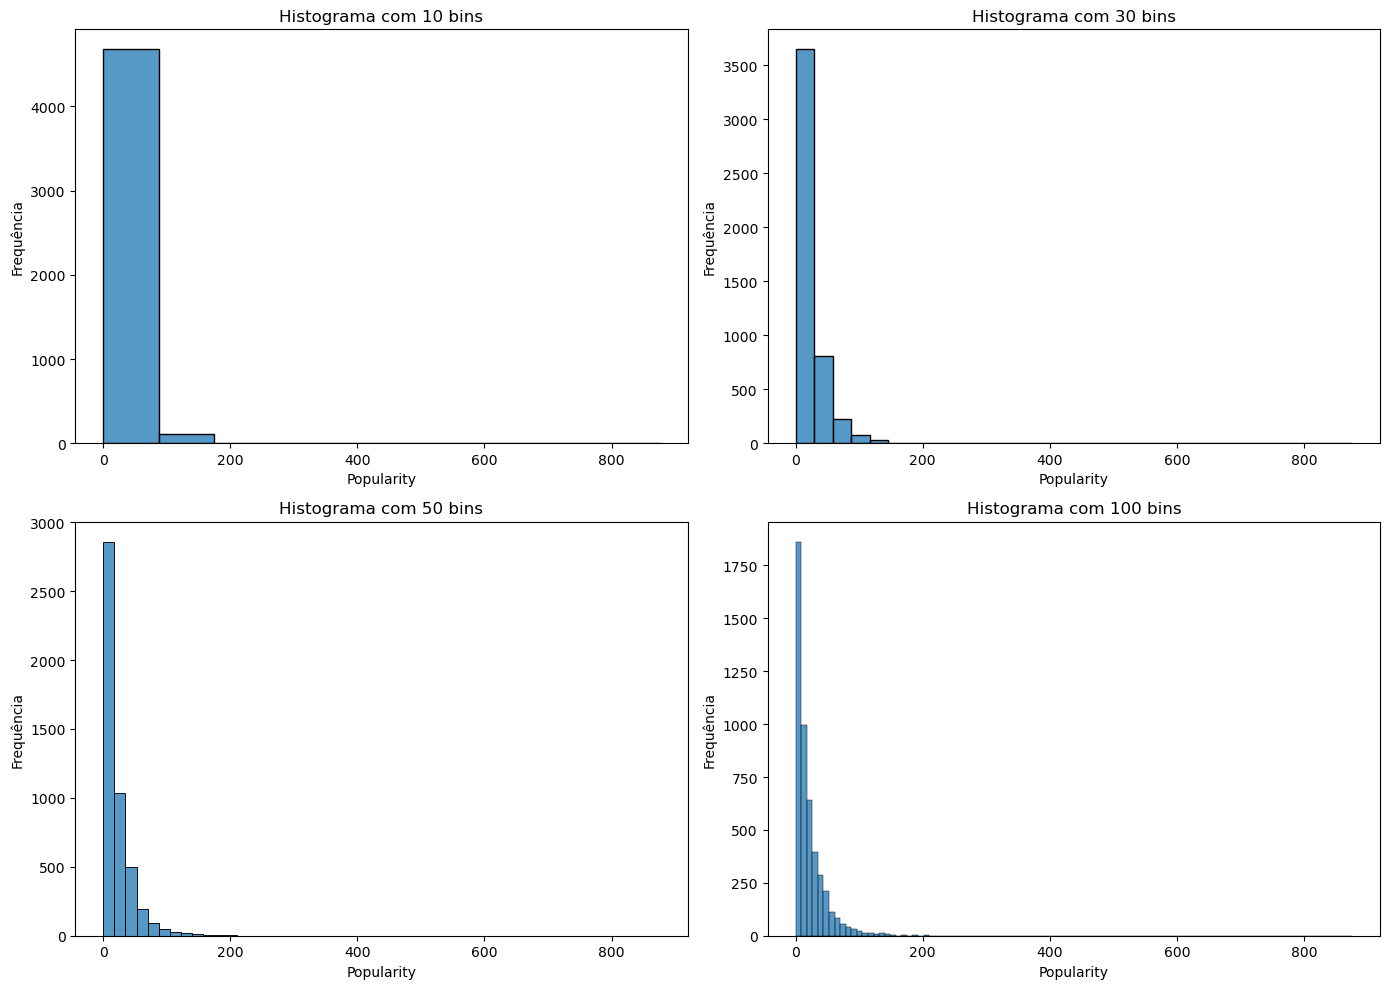

In [89]:
import seaborn as sns

# Defina as quantidades de bins que você quer testar
lista_bins = [10, 30, 50, 100]

# Cria um grid de 2x2 para os gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Facilita a iteração

for ax, b in zip(axes, lista_bins):
    # Plota o histograma em cada "quadrado" do grid
    sns.histplot(df_geral_clean['popularity'], bins=b, ax=ax, kde=False)
    
    ax.set_title(f'Histograma com {b} bins')
    ax.set_xlabel('Popularity')
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

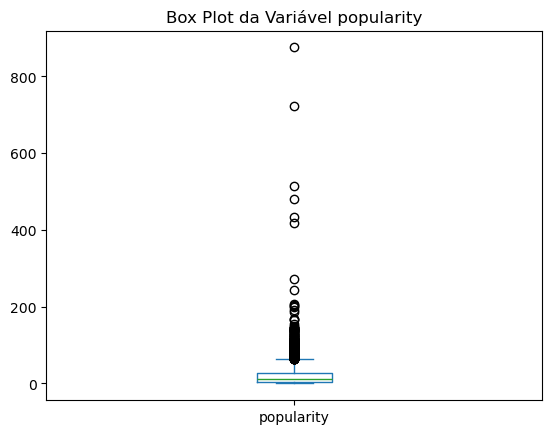

In [73]:
df_geral_clean['popularity'].plot(kind='box')
plt.title('Box Plot da Variável popularity')
plt.show()

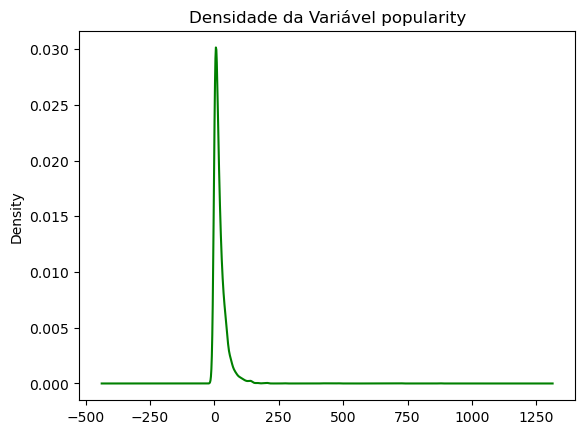

In [75]:
df_geral_clean['popularity'].plot(kind='kde', color='green')
plt.title('Densidade da Variável popularity')
plt.show()

Difícil definir o que seriam os outliers de popularidade pensando em recomendação de filmes. A variável é difícil para trabalhar porque näo é nada simétrica.

Depois de pesquisar, acredito que a melhor decisão seria aplicar transformação logarítimica e DEPOIS.

In [ ]:
df_geral_clean['popularity_log'] = np.log1p(df_geral_clean['popularity'])

C:\Users\Gustavo\AppData\Local\Temp\ipykernel_23744\616864960.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
C:\Users\Gustavo\AppData\Local\Temp\ipykernel_23744\616864960.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
C:\Users\Gustavo\AppData\Local\Temp\ipykernel_23744\616864960.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


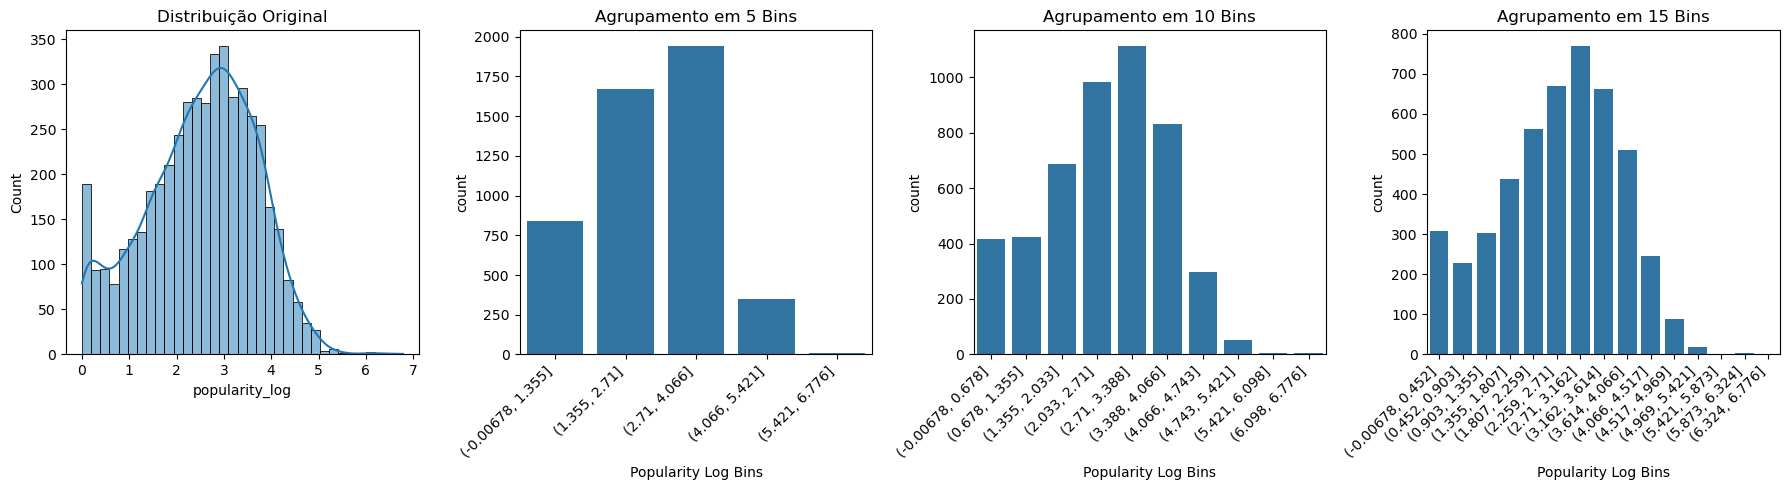

In [ ]:
lista_bins = [5, 10, 15]
df_new = df_geral_clean.copy()

# 1 linha e 4 colunas (1 para o histplot + 3 para os countplots)
# Ajustei o tamanho para (18, 5) para ficar mais compacto
fig, axes = plt.subplots(1, 4, figsize=(18, 5)) 

# 1. Plota o histograma original na primeira posição (eixo 0)
sns.histplot(data=df_new, x="popularity_log", kde=True, ax=axes[0])
axes[0].set_title("Distribuição Original")

# 2. Loop para os countplots
for i, b in enumerate(lista_bins):
    # Divide os dados
    df_new['popularity_bin'] = pd.cut(df_new['popularity_log'], bins=b)
    
    # Define em qual eixo (quadrado) o gráfico vai entrar
    # i+1 pois o índice 0 já foi usado pelo histplot
    ax = axes[i+1] 
    
    # Plota o countplot
    sns.countplot(data=df_new, x="popularity_bin", ax=ax)
    
    # Ajustes visuais do eixo
    ax.set_title(f'Agrupamento em {b} Bins')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
    ax.set_xlabel('Popularity Log Bins')

# Ajusta o espaçamento para que as labels não se sobreponham
plt.tight_layout()
plt.show()

E agora, e se eu winsorizar?

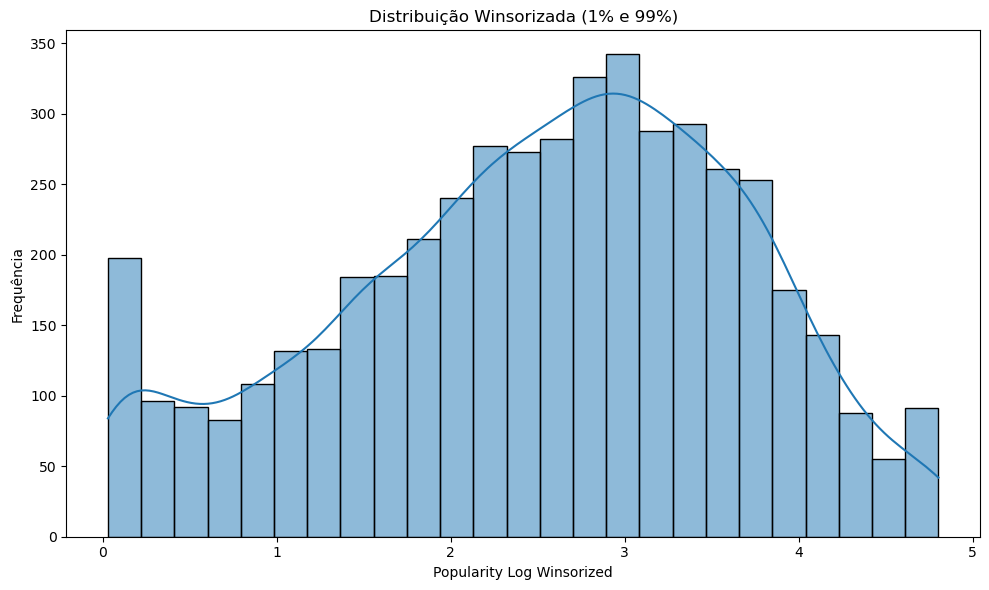

In [114]:
from scipy.stats import mstats

# Winsorizar popularity_log no 1% e 99%
df_new['popularity_log_winsorized'] = mstats.winsorize(df_new['popularity_log'], limits=[0.01, 0.01])

# Plotar a distribuição winsorizada
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_new, x="popularity_log_winsorized", kde=True, ax=ax)
ax.set_title("Distribuição Winsorizada (1% e 99%)")
ax.set_xlabel("Popularity Log Winsorized")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

#### Decisões

In [115]:
# Transformação logarítmica + winsorização de popularidade
df_geral_clean['popularity_log'] = np.log1p(df_geral_clean['popularity'] + 1)
df_geral_clean['popularity_log_win'] = mstats.winsorize(df_geral_clean['popularity_log'], limits=[0.01, 0.01])
df_geral_clean.drop(columns=['popularity', 'popularity_log'], inplace=True)
# Removendo filmes com duração zerada
df_geral_clean = df_geral_clean[df_geral_clean['runtime'] > 0]

In [116]:
num_features = df_geral_clean.drop(columns=['movie_id']).select_dtypes(exclude=['object']).columns
num_features

Index(['runtime', 'vote_average', 'release_year', 'popularity_log_win'], dtype='object')

In [117]:
df_geral_clean[num_features].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,runtime,vote_average,release_year,popularity_log_win
count,4772.000000,4772.000000,4772.000000,4772.000000
mean,107.666178,6.113684,2002.399413,2.662063
std,20.741329,1.143399,12.443464,1.003917
min,14.000000,0.000000,1916.000000,0.707423
1%,76.000000,0.000000,1951.000000,0.711887
10%,87.000000,4.900000,1988.000000,1.221555
25%,94.000000,5.600000,1999.000000,1.923372
50%,104.000000,6.200000,2005.000000,2.718292
75%,118.000000,6.800000,2011.000000,3.419049
90%,132.000000,7.300000,2014.000000,3.931387


### 3.3.2 Categóricas

#### Decisões

In [118]:
cat_features = df_geral_clean.select_dtypes(include=['object']).columns
cat_features

Index(['genres', 'keywords', 'overview', 'title', 'top_3_cast',
       'main_production_company', 'main_production_country', 'main_director',
       'main_producer'],
      dtype='object')